In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

## Загрузка данных

In [2]:
df1 = pd.read_csv("../data/UCI_Credit_Card.csv")
df = df1.copy()
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df = df.drop(columns=["ID"])

In [4]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
TARGET = "default.payment.next.month"
df[TARGET].value_counts(normalize=True)

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [6]:
FEATURES = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
df[FEATURES].shape

(30000, 23)

## EDA

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   30000 non-null

In [8]:
# Пропуски
df.isna().sum().sum()

np.int64(0)

In [9]:
# Дубликаты
df.duplicated().sum()

np.int64(35)

In [10]:
# Удаляем дупликаты
df = df.drop_duplicates()
df.shape

(29965, 24)

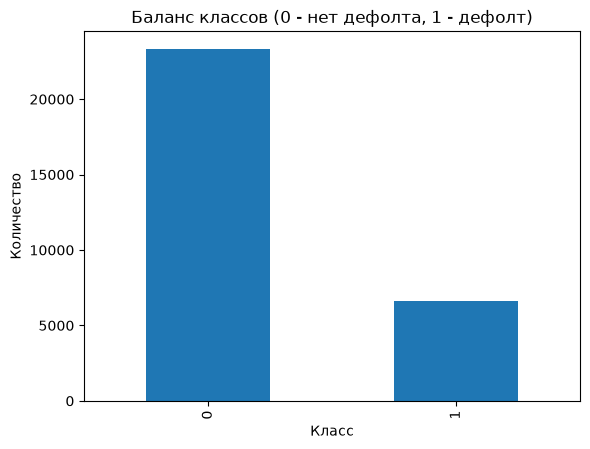

In [11]:
ax = df[TARGET].value_counts().plot(kind="bar")
ax.set_title("Баланс классов (0 - нет дефолта, 1 - дефолт)")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество")
plt.show()

In [12]:
df[TARGET].value_counts(normalize=True)

default.payment.next.month
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Наблюдаем дисбаланс классов

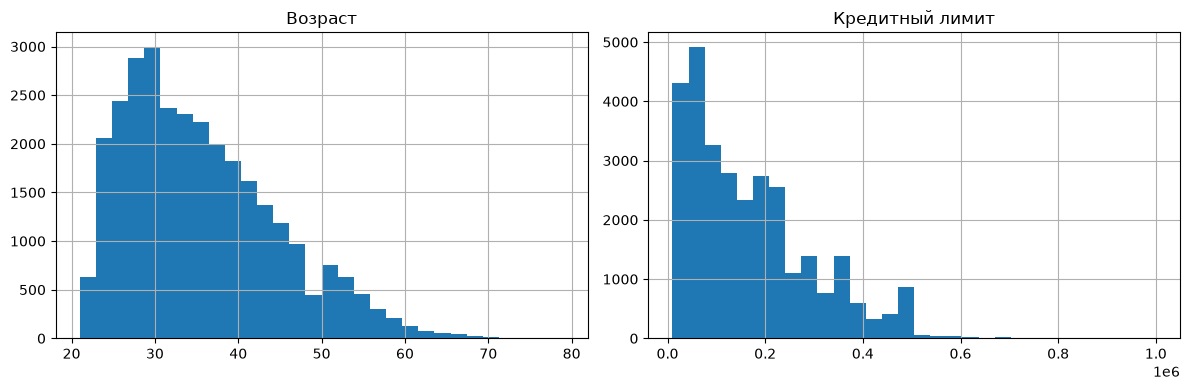

In [13]:
# распределения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["AGE"].hist(bins=30, ax=axes[0])
axes[0].set_title("Возраст")
df["LIMIT_BAL"].hist(bins=30, ax=axes[1])
axes[1].set_title("Кредитный лимит")
plt.tight_layout()
plt.show()

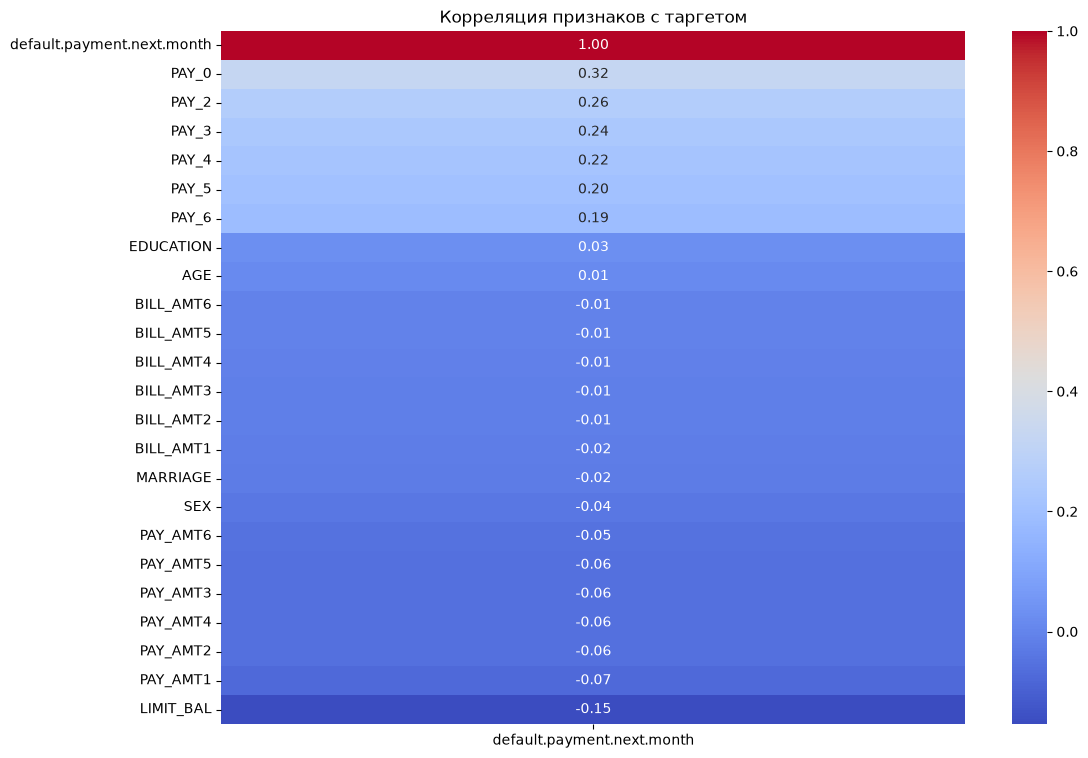

In [14]:
# Корреляции признаков
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr[[TARGET]].sort_values(TARGET, ascending=False), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция признаков с таргетом")
plt.show()

Сильнее всего с дефолтом линейно связаны статусы просрочек. Остальные признаки показывают слабую линеную корреляцию.

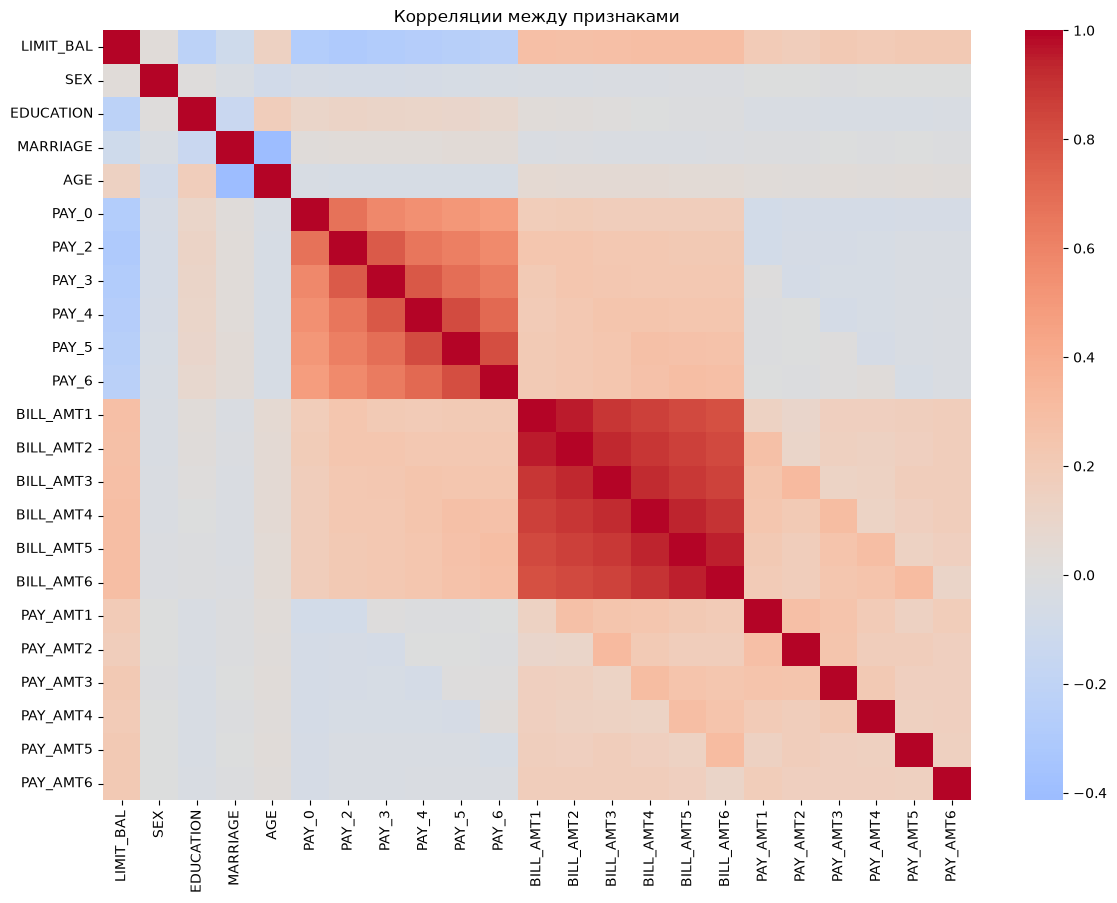

In [15]:
plt.figure(figsize=(14, 10))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Корреляции между признаками")
plt.show()

Наблюдается ожидаемая мультиколлинеарность, признаки BILL_AMT сильно коррелируют, PAY_AMT умеренно, что естественно для данных за соседние месяцы. Остальные признаки независимы. Ничего не удаляем.

## Разбиение данных

In [16]:
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} Test: {X_test.shape}")

Train: (23972, 23) Test: (5993, 23)


## Обучение моделей

In [20]:
def build_models():
    log_reg = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    random_forest = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1)),
    ])
    return {"v1": log_reg, "v2": random_forest}

models = build_models()
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"{name} обучена")

v1 обучена
v2 обучена


In [21]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "f1": round(f1_score(y_test, y_pred, pos_label=1), 4),
        "precision": round(precision_score(y_test, y_pred, pos_label=1), 4),
        "recall": round(recall_score(y_test, y_pred, pos_label=1), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    }

results = {name: evaluate(m, X_test, y_test) for name, m in models.items()}
print(pd.DataFrame(results).T)

        f1  precision  recall  roc_auc
v1  0.4706     0.3756  0.6297   0.7162
v2  0.5296     0.4990  0.5641   0.7720


In [22]:
for name, m in models.items():
    print(f"{name}")
    print(classification_report(y_test, m.predict(X_test), target_names=["нет дефолта", "дефолт"]))

v1
              precision    recall  f1-score   support

 нет дефолта       0.87      0.70      0.78      4667
      дефолт       0.38      0.63      0.47      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.67      0.62      5993
weighted avg       0.76      0.69      0.71      5993

v2
              precision    recall  f1-score   support

 нет дефолта       0.87      0.84      0.85      4667
      дефолт       0.50      0.56      0.53      1326

    accuracy                           0.78      5993
   macro avg       0.69      0.70      0.69      5993
weighted avg       0.79      0.78      0.78      5993



Случайный лес (v2) показывает лучшее качество, F1=0.53 и ROC-AUC=0.772 против F1=0.47 и ROC-AUC=0.716 у логистической регрессии (v1). У логистической регрессии высокий recall ценой низкого precision, однако это не делает его лучше для нашей задачи, так как подобрав порог случайный лес скорее всего обеспечит более высокий precision при том же recall.